In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

DB_PATH = "../data/portfolio_ml.duckdb"

con = duckdb.connect(DB_PATH)

In [4]:
df = con.execute("""
SELECT *
FROM read_parquet('../data/marts/features/**/*.parquet')
ORDER BY date, symbol
""").df()

df.head()

,date,symbol,return_1d,log_return_1d,return_5d,return_21d,return_63d,volatility_21d,volatility_63d,momentum_21d,momentum_63d,drawdown,rolling_volume_21d,price_to_ma_21,price_to_ma_63,target_return_1d,target_return_5d,created_at,year
0,2018-01-02,DBC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3995700.0,0.0,0.0,0.005992,0.007190,2026-06-25 18:58:10.527461+03:30,2018
1,2018-01-02,DIA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,4454900.0,0.0,0.0,0.003750,0.023385,2026-06-25 18:58:10.527461+03:30,2018
2,2018-01-02,EEM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,68969400.0,0.0,0.0,0.009581,0.021662,2026-06-25 18:58:10.527461+03:30,2018
3,2018-01-02,EFA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,26530000.0,0.0,0.0,0.004800,0.022307,2026-06-25 18:58:10.527461+03:30,2018
4,2018-01-02,GLD,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,11762500.0,0.0,0.0,-0.002637,-0.003356,2026-06-25 18:58:10.527461+03:30,2018


In [6]:
df.shape

(21310, 19)

In [7]:
df.columns

Index(['date', 'symbol', 'return_1d', 'log_return_1d', 'return_5d',
       'return_21d', 'return_63d', 'volatility_21d', 'volatility_63d',
       'momentum_21d', 'momentum_63d', 'drawdown', 'rolling_volume_21d',
       'price_to_ma_21', 'price_to_ma_63', 'target_return_1d',
       'target_return_5d', 'created_at', 'year'],
      dtype='object')

In [8]:
df.dtypes

date                               datetime64[us]
symbol                                     object
return_1d                                 float64
log_return_1d                             float64
return_5d                                 float64
return_21d                                float64
return_63d                                float64
volatility_21d                            float64
volatility_63d                            float64
momentum_21d                              float64
momentum_63d                              float64
drawdown                                  float64
rolling_volume_21d                        float64
price_to_ma_21                            float64
price_to_ma_63                            float64
target_return_1d                          float64
target_return_5d                          float64
created_at            datetime64[us, Asia/Tehran]
year                                        int64
dtype: object

In [10]:
df.symbol.unique()

array(['DBC', 'DIA', 'EEM', 'EFA', 'GLD', 'IWM', 'QQQ', 'SPY', 'TLT',
       'VNQ'], dtype=object)

In [12]:
df.date.min(), df.date.max()

(Timestamp('2018-01-02 00:00:00'), Timestamp('2026-06-25 00:00:00'))

In [13]:
df.groupby("symbol").size()

symbol
DBC    2131
DIA    2131
EEM    2131
EFA    2131
GLD    2131
IWM    2131
QQQ    2131
SPY    2131
TLT    2131
VNQ    2131
dtype: int64

In [14]:
duplicates = df.duplicated(subset=["symbol", "date"]).sum()
duplicates

0

In [15]:
df.isna().sum().sort_values(ascending=False)

return_63d            630
momentum_63d          630
momentum_21d          210
return_21d            210
volatility_63d        100
volatility_21d         50
return_5d              50
target_return_5d       50
log_return_1d          10
return_1d              10
target_return_1d       10
symbol                  0
date                    0
drawdown                0
rolling_volume_21d      0
price_to_ma_63          0
price_to_ma_21          0
created_at              0
year                    0
dtype: int64

/home/arshiaask/projects/venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='return_1d', ylabel='Count'>

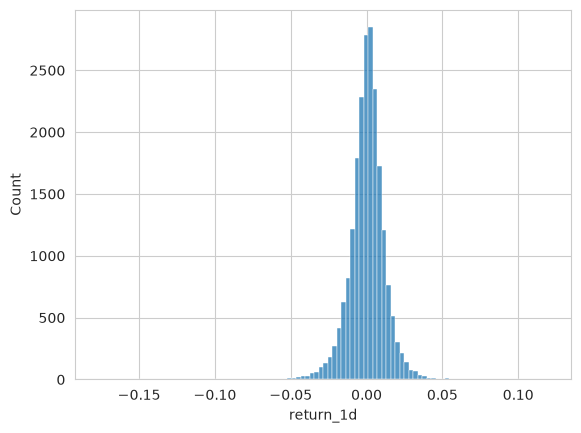

In [17]:
sns.histplot(df["return_1d"], bins=100)

In [18]:
df["return_1d"].describe()

count    21300.000000
mean         0.000438
std          0.012623
min         -0.177277
25%         -0.005572
50%          0.000836
75%          0.006882
max          0.120031
Name: return_1d, dtype: float64

/home/arshiaask/projects/venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/arshiaask/projects/venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/arshiaask/projects/venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/arshiaask/projects/venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed

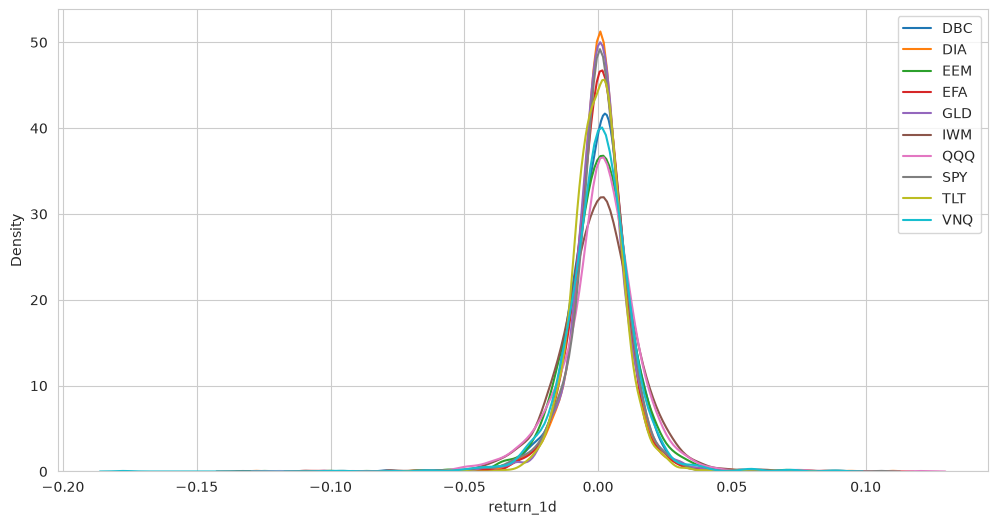

In [19]:
plt.figure(figsize=(12,6))

for symbol in df.symbol.unique():
    sns.kdeplot(
        df[df.symbol == symbol]["return_1d"],
        label=symbol
    )

plt.legend()

/home/arshiaask/projects/venv/lib/python3.12/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='volatility_21d', ylabel='Count'>

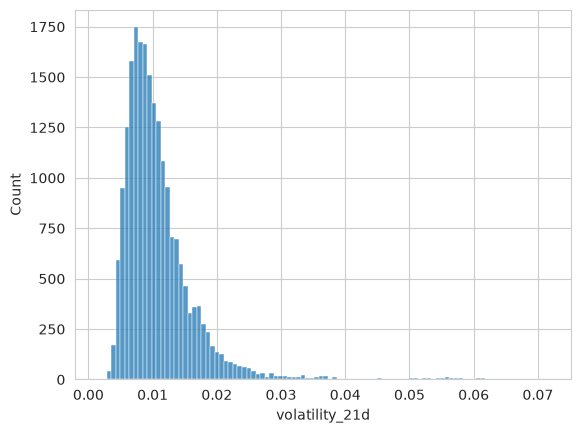

In [20]:
sns.histplot(df["volatility_21d"], bins=100)

In [21]:
df.groupby("symbol")["volatility_21d"].mean()

symbol
DBC    0.010757
DIA    0.009746
EEM    0.012120
EFA    0.009894
GLD    0.009528
IWM    0.013812
QQQ    0.013360
SPY    0.010180
TLT    0.008944
VNQ    0.011677
Name: volatility_21d, dtype: float64

Text(0.5, 1.0, 'SPY Daily Returns')

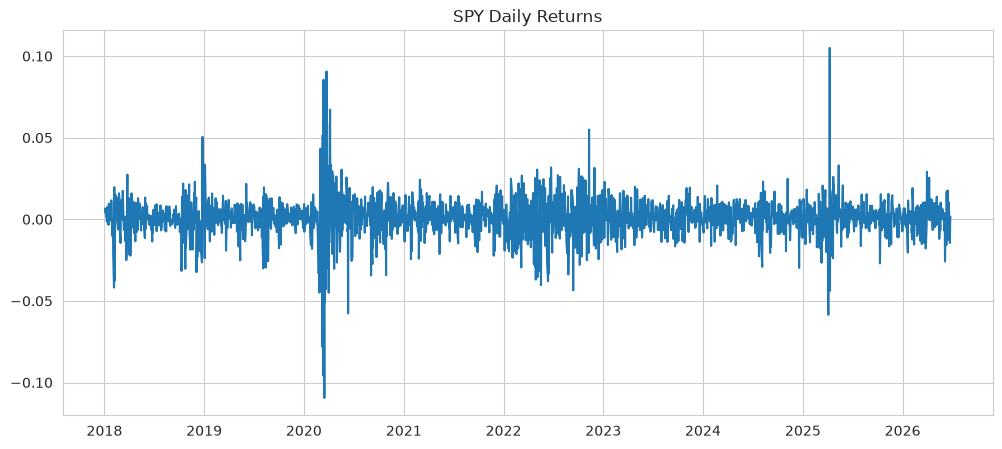

In [22]:
spy = df[df.symbol == "SPY"]

plt.figure(figsize=(12,5))
plt.plot(spy.date, spy.return_1d)
plt.title("SPY Daily Returns")


In [23]:
returns = df.pivot(
    index="date",
    columns="symbol",
    values="return_1d"
)

In [ ]:
corr = returns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
corr


symbol,DBC,DIA,EEM,EFA,GLD,IWM,QQQ,SPY,TLT,VNQ
symbol,,,,,,,,,,
DBC,1.000000,0.315133,0.321302,0.323840,0.279416,0.315324,0.255358,0.319550,-0.164603,0.223510
DIA,0.315133,1.000000,0.709905,0.841153,0.092999,0.852421,0.807602,0.944123,-0.172736,0.751297
EEM,0.321302,0.709905,1.000000,0.831156,0.262569,0.704069,0.736294,0.752227,-0.089742,0.539868
EFA,0.323840,0.841153,0.831156,1.000000,0.243172,0.804425,0.760065,0.851894,-0.090385,0.688717
GLD,0.279416,0.092999,0.262569,0.243172,1.000000,0.124796,0.129533,0.116247,0.226938,0.138583
IWM,0.315324,0.852421,0.704069,0.804425,0.124796,1.000000,0.770692,0.866889,-0.107799,0.738505
QQQ,0.255358,0.807602,0.736294,0.760065,0.129533,0.770692,1.000000,0.937011,-0.089814,0.584549
SPY,0.319550,0.944123,0.752227,0.851894,0.116247,0.866889,0.937011,1.000000,-0.138410,0.734908
TLT,-0.164603,-0.172736,-0.089742,-0.090385,0.226938,-0.107799,-0.089814,-0.138410,1.000000,0.026450


In [28]:
feature_cols = [c for c in df.columns if c not in ["date","symbol","target_return_1d"]]

corr = df[feature_cols + ["target_return_1d"]].corr()

corr["target_return_1d"].sort_values(ascending=False)

target_return_1d      1.000000
target_return_5d      0.430895
volatility_63d        0.040328
volatility_21d        0.033118
rolling_volume_21d    0.013769
year                  0.011584
drawdown             -0.017164
return_21d           -0.017490
momentum_21d         -0.017490
return_5d            -0.022016
return_63d           -0.027085
momentum_63d         -0.027085
price_to_ma_63       -0.031262
price_to_ma_21       -0.032183
return_1d            -0.082536
log_return_1d        -0.082982
created_at                 NaN
Name: target_return_1d, dtype: float64

In [29]:
df["return_1d"].abs().sort_values(ascending=False).head(20)

5539     0.177277
5535     0.132669
5531     0.127612
5532     0.124792
18276    0.120031
5536     0.119788
5515     0.110502
5591     0.110192
5513     0.109902
5537     0.109424
18277    0.105019
5533     0.103194
20304    0.102742
5519     0.101303
5511     0.100619
5512     0.100107
5485     0.097230
5517     0.095677
5559     0.095128
5521     0.094291
Name: return_1d, dtype: float64

In [30]:
returns.index.to_series().diff().value_counts()

date
1 days    1664
3 days     384
4 days      58
2 days      24
Name: count, dtype: int64

In [31]:
df.groupby(
    pd.qcut(df.momentum_21d, 10)
)["target_return_1d"].mean()

/tmp/ipykernel_359188/1231558616.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


momentum_21d
(-0.425, -0.0521]      0.000795
(-0.0521, -0.0285]     0.000716
(-0.0285, -0.0129]    -0.000082
(-0.0129, 0.000279]    0.000398
(0.000279, 0.0112]     0.000314
(0.0112, 0.0222]       0.000282
(0.0222, 0.0333]       0.000276
(0.0333, 0.0471]       0.000229
(0.0471, 0.0682]       0.000694
(0.0682, 0.284]        0.000691
Name: target_return_1d, dtype: float64